#  Impact of AOCS jitter on the photometry at camera level

$\textbf{Goals}$

Test the impact and behavior of spacecraft Attitude and Orbital Control System (AOCS) jitter on camera level. 

$\textbf{Context}$

In order to achieve the required noise budget at mission level, the PMC has defined Mean Pointing Error and Relative Pointing Error requirements at camera level. In the high frequency range ($f \gg 0.04$Hz), the dominant contribution results from the performance of the attitude and orbit control system of the S/C (jitter).

$\textbf{Simulations}$

To test the impact of jitter it should be enough to have several short-term simulations (1 day long), for 24 N-CAMs and several quarters. Specifically one simulation with fast jitter (8 Hz), and one simulation without jitter (only white noise jitter) shall be compared to tell whether a jitter correction on-ground is mandatory or not. 
Prime have delivered a high frequency jitter simulations for one N-Cam w.r.t. to F2-Cam with a cadence of 8 Hz and duration of 27h. We shall investigate if this simulation can be cycled to the remaining cameras and how this might impact the forthcoming analysis.

As a baseline, we keep on-ground processing as an option for WC of the impact of jitter.

$\textbf{Data analysis}$

In [21]:
%matplotlib inline

import os
import h5py
import numpy as np
import pandas as pd
from scipy.interpolate import make_interp_spline
from scipy.ndimage import median_filter
from scipy import constants as c

# PlatoSim
import platosim.plot

# Handle warnings
import warnings
warnings.filterwarnings('ignore')

# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
plt.rcParams.update({'font.size': 15})
plt.rcParams['text.usetex'] = True

### Functions

In [23]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

### User defined parameters

In [24]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
workdir  = '/lhome/nicholas/software/workdir/kul21/input'
inputdir = '/lhome/nicholas/software/PlatoSim/inputfiles'
aocsdir  = '/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/2020jan'
ra  = 86.79870508
dec = -46.39594703
rot = -4.
sigma = 3
quarters = np.arange(1,9) # Q1-Q8

## 1) Pointing errors 

### 1.1) Prime CM LOS AOCS + TED

Each LOS variable has a sample rate of 8Hz and is in radians. The periods where reaction wheel offloading were simulated, including a
tranquilisation time after the transition from OLM back to GAM are set to `NaN`.

In [52]:
# Load Prime 
f = h5py.File('CM_LOS_Combined_v2.mat', 'r')
xLOS = f['LOSX'][0]
yLOS = f['LOSY'][0]
zLOS = f['LOSZ'][0]

# Shorten time series and create time points
t = 0.125
l = int(24 * 3600 / t)
time = np.arange(0, len(xLOS), t)  # 8 Hz
signals = [xLOS[:l], yLOS[:l], zLOS[:l]]

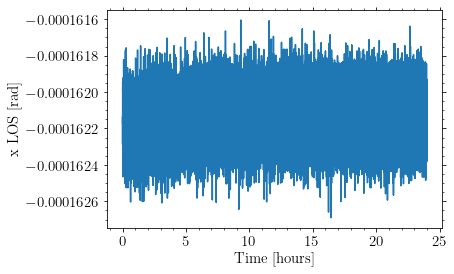

In [51]:
# Plot x LOS for illustration
plt.plot(time[:l]/3600, xLOS[:l], '-')
plt.xlabel('Time [hours]')
plt.ylabel('x LOS [rad]')
plt.show()

### 1.1) AOCS jitter time series from Prime

We use the $8\,\rm Hz$ AOCS jitter time series simulated delivered by the ESA Prime contractor the 2021-01-09. See the technidal note: *Description of pointing data delivery as part of System PDR* (`PTO-OHB-SYS-MEM-0222 i.1.0`). This dataset consist of several simulations of which the first called `PLATO_PDR_FPM_02_longrun_APE`. 

In [25]:
df = pd.read_csv(f'{aocsdir}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])
df.head()

,t,x,y,z
0,1000.000,0.000001,9.850000e-07,2.750000e-07
1,1000.125,0.000001,9.780000e-07,2.940000e-07
2,1000.250,0.000001,9.840000e-07,3.200000e-07
3,1000.375,0.000001,9.960000e-07,3.510000e-07
4,1000.500,0.000001,1.000000e-06,3.770000e-07


In [26]:
# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


In [27]:
# Split time from signals to adapt to plots below
data = df.to_numpy()
time    = data[:,0]
signals = data[:,1:]

In [28]:
# Save jitter file
np.savetxt(f'{workdir}/AOCS_Prime_2020jan_longrun_28h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

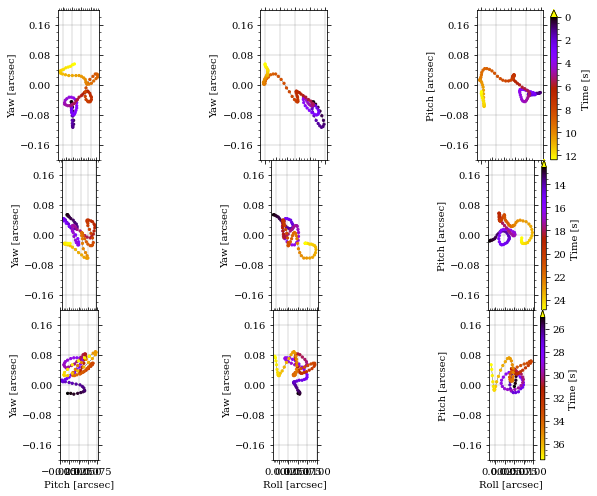

In [29]:
# Plot 
platosim.plot.plotYawPitchRollJitter(time, signals.T, clabel='Time [s]', title='AOCS time series')
plt.show()

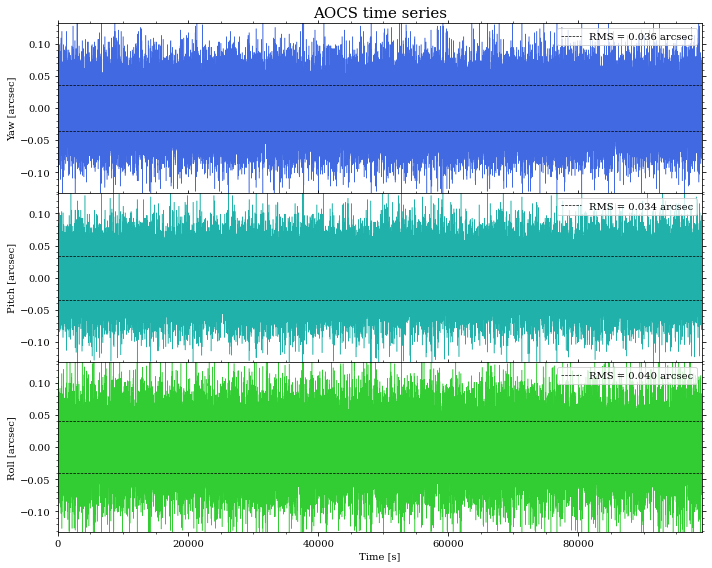

In [30]:
# Plot AOCS time series and the RMS of each component
fig = plt.figure(figsize=(10,8))
platosim.plot.plotYawPitchRollTimeSeries(fig, time, signals.T, ['s', 'arcsec'], 'AOCS time series')
plt.show()

AttributeError: module 'platosim.noise' has no attribute 'powerDensityFFT'

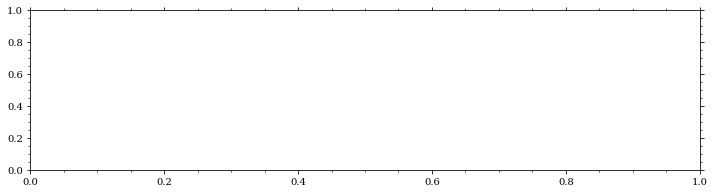

In [31]:
# Plot# Plot the Power Spectral Density (PSD)
fig = plt.figure(figsize=(12,10))
platosim.plot.plotYawPitchRollPSD(fig, time, signals.T, labels=['s', 'arcsec'], title='AOCS time series')
plt.show()

### 1.2) Pointing Reproducibility Error (PRE)

In [ ]:
# Coordinates
ICRS = np.array([ra, dec, rot])

# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{outdir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

# Print generated values
print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)
print('\nChange of coordinates [arcsec]')
print(coor*3600)
print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

### 1.3) Camera alignment errors in yaw, pitch, and roll (x, y, z)

In [ ]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz
mu, sigma = 0, sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)

# Plot histogram and data
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
np.savetxt('APE.txt', np.transpose([tt, bb]), fmt='%.8f')

# Print generate values
print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)

---

## Data Analysis